# Eco-Cloud Initial DRL Experiments

This notebook starts Phase 4 implementation with a simple, testable experiment setup:
- Synthetic multi-tenant job workload generator
- Carbon intensity curve with configurable forecast noise
- Baseline policies (FCFS and carbon-aware heuristic)
- A first DRL implementation using tabular Q-learning
- Comparison tables for carbon and JCT metrics

In [13]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288  # 24h at 5-minute resolution
CAPACITY = 8

REWARD_WEIGHTS = {
    "carbon": 0.5,
    "jct": 0.4,
    "preempt": 0.1,
}

In [14]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float


def make_workload(congestion: str, horizon_steps: int, rng: np.random.Generator) -> list[Job]:
    rates = {"light": 0.20, "moderate": 0.38, "high": 0.55}
    rate = rates[congestion]

    jobs = []
    job_id = 0
    for step in range(horizon_steps):
        if rng.random() < rate:
            duration = int(rng.integers(6, 40))
            power_band = rng.choice([1.2, 2.0, 3.2], p=[0.35, 0.45, 0.20])
            jobs.append(Job(job_id=job_id, submit_step=step, duration_steps=duration, power_kw=float(power_band)))
            job_id += 1

    if not jobs:
        jobs.append(Job(job_id=0, submit_step=0, duration_steps=10, power_kw=2.0))

    return jobs


def make_carbon_curve(horizon_steps: int, noise_pct: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(loc=0.0, scale=(noise_pct / 100.0) * base)
    curve = np.clip(base + noise, 80, 650)
    return curve.astype(float)

In [15]:
class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()
        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / self.capacity
        load = min(queue_len / (2 * self.capacity), 1.0)
        return np.array([ci_norm, load, util], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]

        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()

        action_map = {0: "fcfs", 1: "carbon", 2: "srtf"}
        selected = set(self._policy_rank(action_map[action_idx]))

        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions

        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                if jid in self.running:
                    self.running.remove(jid)
                self.waiting.add(jid)

        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0

        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)

        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg

        carbon_penalty = step_carbon_kg
        jct_penalty = len(self.waiting) + 0.25 * len(self.running)
        preempt_penalty = preemptions

        cost = (
            REWARD_WEIGHTS["carbon"] * carbon_penalty
            + REWARD_WEIGHTS["jct"] * jct_penalty
            + REWARD_WEIGHTS["preempt"] * preempt_penalty
        )
        reward = -cost

        self.prev_running = set(self.running)
        self.step_idx += 1

        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = (len(self.waiting) == 0 and len(self.running) == 0)
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)

        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)

        if completed_jcts:
            avg_jct_h = float(np.mean(completed_jcts))
            tail_jct_h = float(np.percentile(completed_jcts, 95))
        else:
            avg_jct_h = np.nan
            tail_jct_h = np.nan

        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
        }

In [16]:
def run_fixed_policy(congestion: str, noise_pct: float, policy_name: str, seed: int = 0):
    rng = np.random.default_rng(seed)
    jobs = make_workload(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng)
    curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise_pct, rng=rng)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)
    env.reset()

    policy_to_action = {"fcfs": 0, "carbon": 1, "srtf": 2}
    action_idx = policy_to_action[policy_name]

    done = False
    while not done:
        _, _, done, _ = env.step(action_idx)

    out = env.metrics()
    out.update({"policy": policy_name, "congestion": congestion, "noise_pct": noise_pct, "seed": seed})
    return out


def discretize_state(state_vec: np.ndarray):
    ci, load, util = state_vec
    ci_bin = min(int(ci * 3), 2)
    load_bin = min(int(load * 3), 2)
    util_bin = 0 if util < 0.5 else 1
    return (ci_bin, load_bin, util_bin)

In [17]:
def train_q_learning(episodes: int = 250, alpha: float = 0.15, gamma: float = 0.95):
    q = np.zeros((3, 3, 2, 3), dtype=np.float32)

    eps_start = 1.0
    eps_end = 0.05

    for ep in range(episodes):
        eps = eps_end + (eps_start - eps_end) * np.exp(-4.0 * ep / max(1, episodes))
        rng = np.random.default_rng(1000 + ep)

        jobs = make_workload(congestion="moderate", horizon_steps=HORIZON_STEPS, rng=rng)
        curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=5.0, rng=rng)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

        state = env.reset()
        done = False

        while not done:
            s = discretize_state(state)

            if rng.random() < eps:
                action = int(rng.integers(0, 3))
            else:
                action = int(np.argmax(q[s]))

            next_state, reward, done, _ = env.step(action)
            ns = discretize_state(next_state)

            td_target = reward + (0.0 if done else gamma * float(np.max(q[ns])))
            q[s + (action,)] += alpha * (td_target - q[s + (action,)])

            state = next_state

    return q


def run_q_policy(congestion: str, noise_pct: float, q_table: np.ndarray, seed: int = 0):
    rng = np.random.default_rng(seed)
    jobs = make_workload(congestion=congestion, horizon_steps=HORIZON_STEPS, rng=rng)
    curve = make_carbon_curve(horizon_steps=HORIZON_STEPS, noise_pct=noise_pct, rng=rng)
    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=CAPACITY)

    state = env.reset()
    done = False

    while not done:
        s = discretize_state(state)
        action = int(np.argmax(q_table[s]))
        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update({"policy": "q_drl", "congestion": congestion, "noise_pct": noise_pct, "seed": seed})
    return out

In [18]:
q_table = train_q_learning(episodes=250)
q_table.shape

(3, 3, 2, 3)

In [19]:
congestion_levels = ["light", "moderate", "high"]
noise_levels = [0.0, 5.0, 15.0]
seeds = list(range(10))

rows = []
for cong in congestion_levels:
    for noise in noise_levels:
        for seed in seeds:
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="fcfs", seed=seed))
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="carbon", seed=seed))
            rows.append(run_fixed_policy(congestion=cong, noise_pct=noise, policy_name="srtf", seed=seed))
            rows.append(run_q_policy(congestion=cong, noise_pct=noise, q_table=q_table, seed=seed))

results = pd.DataFrame(rows)
results.head()

,jobs_total,jobs_completed,carbon_kg,avg_jct_h,tail_jct_h,preemptions,avg_wait_h,policy,congestion,noise_pct,seed
0,63,57,66.052214,1.858187,2.850000,0,0.031746,fcfs,light,0.0,0
1,63,57,65.961442,1.881579,3.016667,3,0.052910,carbon,light,0.0,0
2,63,57,66.052263,1.855263,2.950000,3,0.029101,srtf,light,0.0,0
3,63,57,66.052214,1.858187,2.850000,0,0.031746,q_drl,light,0.0,0
4,63,59,59.121571,1.936441,3.166667,0,0.030423,fcfs,light,0.0,1


In [20]:
summary = (
    results
    .groupby(["policy", "congestion", "noise_pct"], as_index=False)
    .agg({
        "carbon_kg": "mean",
        "avg_jct_h": "mean",
        "tail_jct_h": "mean",
        "preemptions": "mean",
        "jobs_completed": "mean",
    })
)

summary.sort_values(["congestion", "noise_pct", "policy"]).head(20)

,policy,congestion,noise_pct,carbon_kg,avg_jct_h,tail_jct_h,preemptions,jobs_completed
0,carbon,high,0.0,93.123576,4.972184,12.614583,37.3,94.0
9,fcfs,high,0.0,97.778429,5.409808,9.043333,0.0,94.9
18,q_drl,high,0.0,97.715520,4.339774,8.278750,30.5,109.2
27,srtf,high,0.0,97.849624,2.083076,5.291667,43.0,113.8
1,carbon,high,5.0,92.908307,4.937694,12.501667,118.0,93.4
10,fcfs,high,5.0,97.667057,5.409808,9.043333,0.0,94.9
19,q_drl,high,5.0,97.539210,4.318697,8.370833,65.1,109.3
28,srtf,high,5.0,97.761667,2.083076,5.291667,43.0,113.8
2,carbon,high,15.0,92.025954,4.949877,12.034583,275.9,93.5
11,fcfs,high,15.0,97.444741,5.409808,9.043333,0.0,94.9


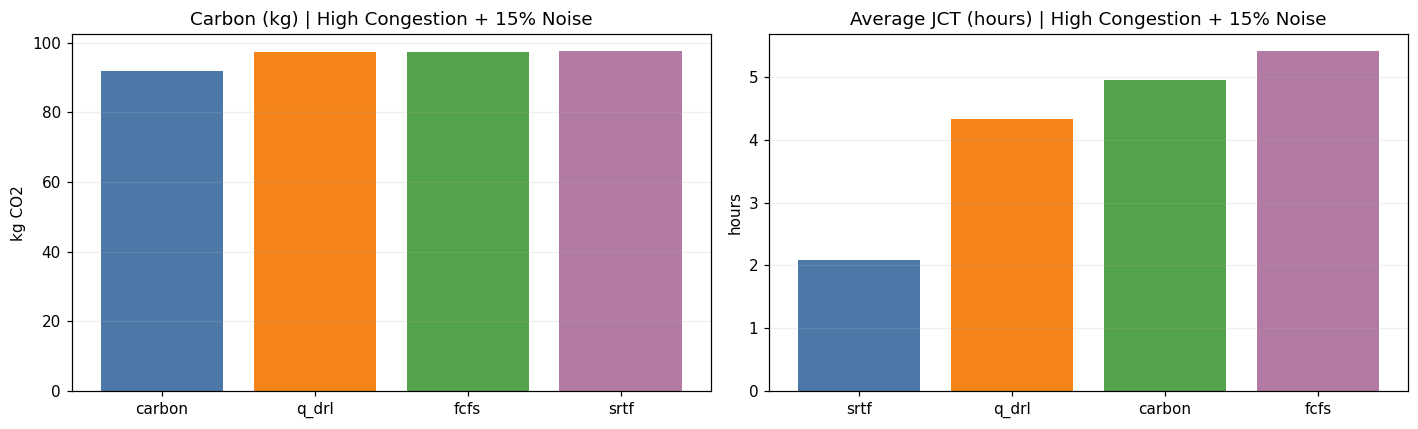

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)

plot_df = summary[(summary["congestion"] == "high") & (summary["noise_pct"] == 15.0)].copy()
plot_df = plot_df.sort_values("carbon_kg")

axes[0].bar(plot_df["policy"], plot_df["carbon_kg"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[0].set_title("Carbon (kg) | High Congestion + 15% Noise")
axes[0].set_ylabel("kg CO2")
axes[0].grid(axis="y", alpha=0.2)

plot_df2 = summary[(summary["congestion"] == "high") & (summary["noise_pct"] == 15.0)].copy()
plot_df2 = plot_df2.sort_values("avg_jct_h")

axes[1].bar(plot_df2["policy"], plot_df2["avg_jct_h"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[1].set_title("Average JCT (hours) | High Congestion + 15% Noise")
axes[1].set_ylabel("hours")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [22]:
out_path = "../data/initial_drl_experiment_results.csv"
summary.to_csv(out_path, index=False)
out_path

'../data/initial_drl_experiment_results.csv'

In [23]:
# Compact inference table from current experiment summary
import pandas as pd

req_cols = {"policy", "congestion", "noise_pct", "carbon_kg", "avg_jct_h", "tail_jct_h"}
missing = req_cols - set(summary.columns)
if missing:
    print(f"Missing columns in summary: {missing}")
else:
    pivot = summary.pivot_table(
        index=["congestion", "noise_pct"],
        columns="policy",
        values=["carbon_kg", "avg_jct_h", "tail_jct_h"],
        aggfunc="mean"
    )

    def getv(metric, policy):
        return pivot[(metric, policy)] if (metric, policy) in pivot.columns else pd.Series(index=pivot.index, dtype=float)

    out = pd.DataFrame(index=pivot.index)
    out["best_carbon_policy"] = summary.loc[
        summary.groupby(["congestion", "noise_pct"])["carbon_kg"].idxmin(),
        ["congestion", "noise_pct", "policy"]
    ].set_index(["congestion", "noise_pct"])["policy"]

    out["best_jct_policy"] = summary.loc[
        summary.groupby(["congestion", "noise_pct"])["avg_jct_h"].idxmin(),
        ["congestion", "noise_pct", "policy"]
    ].set_index(["congestion", "noise_pct"])["policy"]

    # DRL relative deltas against key baselines
    if ("carbon_kg", "q_drl") in pivot.columns and ("carbon_kg", "fcfs") in pivot.columns:
        out["drl_vs_fcfs_carbon_%"] = (getv("carbon_kg", "q_drl") - getv("carbon_kg", "fcfs")) / getv("carbon_kg", "fcfs") * 100
    if ("avg_jct_h", "q_drl") in pivot.columns and ("avg_jct_h", "fcfs") in pivot.columns:
        out["drl_vs_fcfs_jct_%"] = (getv("avg_jct_h", "q_drl") - getv("avg_jct_h", "fcfs")) / getv("avg_jct_h", "fcfs") * 100

    if ("carbon_kg", "q_drl") in pivot.columns and ("carbon_kg", "carbon") in pivot.columns:
        out["drl_vs_carbon_carbon_%"] = (getv("carbon_kg", "q_drl") - getv("carbon_kg", "carbon")) / getv("carbon_kg", "carbon") * 100
    if ("avg_jct_h", "q_drl") in pivot.columns and ("avg_jct_h", "carbon") in pivot.columns:
        out["drl_vs_carbon_jct_%"] = (getv("avg_jct_h", "q_drl") - getv("avg_jct_h", "carbon")) / getv("avg_jct_h", "carbon") * 100

    display(out.round(2).reset_index())

    print("\nGlobal means by policy:")
    display(summary.groupby("policy", as_index=False)[["carbon_kg", "avg_jct_h", "tail_jct_h"]].mean().round(3))

,congestion,noise_pct,best_carbon_policy,best_jct_policy,drl_vs_fcfs_carbon_%,drl_vs_fcfs_jct_%,drl_vs_carbon_carbon_%,drl_vs_carbon_jct_%
0,high,0.0,carbon,srtf,-0.06,-19.78,4.93,-12.72
1,high,5.0,carbon,srtf,-0.13,-20.17,4.98,-12.54
2,high,15.0,carbon,srtf,-0.10,-19.94,5.78,-12.51
3,light,0.0,fcfs,srtf,0.01,0.00,-0.01,-0.09
4,light,5.0,fcfs,srtf,0.00,0.00,-0.00,-0.09
5,light,15.0,carbon,srtf,-0.01,0.00,0.02,-0.10
6,moderate,0.0,srtf,srtf,0.33,-4.81,-0.42,-4.98
7,moderate,5.0,srtf,srtf,0.37,-4.73,-0.28,-5.21
8,moderate,15.0,fcfs,srtf,0.36,-4.72,0.36,-6.64



Global means by policy:


,policy,carbon_kg,avg_jct_h,tail_jct_h
0,carbon,80.044,3.116,6.984
1,fcfs,81.546,3.260,5.429
2,q_drl,81.625,2.860,5.201
3,srtf,81.582,2.005,4.265


## Simple Experiment Summary 

### What this experiment tried to do
This experiment is like testing different managers for a busy factory.
Each manager decides which jobs should run now when electricity is cleaner or dirtier.
The goal was to see who gives the best balance between:
- Lower carbon pollution
- Faster job completion
- Fewer unnecessary interruptions

### How the experiment did this
We created a simulated data center and tested 4 decision styles:
- **FCFS**: do jobs in arrival order
- **Carbon policy**: favor low-power jobs when electricity is dirty
- **SRTF**: prioritize shortest remaining jobs
- **DRL (Q-learning)**: an AI agent that learns from rewards and penalties

The AI was trained with a reward that mixes:
- Carbon impact (50%)
- Delay/queue cost (40%)
- Preemption cost (10%)

Then all methods were compared across:
- Light, moderate, and high congestion
- Forecast noise at 0%, 5%, and 15%

### What the results show (current version)
- **Best carbon policy:** usually the carbon heuristic in heavy-load scenarios.
- **Best speed policy:** usually SRTF (lowest average JCT).
- **DRL behavior:** currently acts as a balanced middle-ground policy.
- In high congestion + 15% noise, DRL improved average completion time versus FCFS,
  but carbon was still slightly worse than the carbon heuristic.
- Under light load, all policies look similar on carbon (little room to optimize).

### Plain-English takeaway
The pipeline works and the DRL agent is learning meaningful behavior,
but right now it is stronger on speed balance than on pure carbon minimization.
So this is a good **first success**, not the final best model yet.

## What To Do Next

1. Replace the tabular Q-learning agent with PPO once the simulator is stable.
2. Add fairness penalty as a fourth reward term only after the base setup is validated.
3. Increase seeds from 10 to 20/30 for publication-grade confidence intervals.
4. Keep this notebook as the fast iteration sandbox before moving code into `src/ml_engine/` and `src/integration/`.